# Data Exploratory

- Peak GCVI
- District yield
- Location: India, Season: Kharif

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ee
import geemap
import rasterio as rio
import numpy as np
import geopandas as gpd
import seaborn as sns

In [19]:
ee.Authenticate()
ee.Initialize(project='earth-intelligence-492621')


Successfully saved authorization token.


## GCVI

In [48]:
ee.Initialize(project='earth-intelligence-492621')

peak_gcvi = ee.Image('projects/earth-intelligence-492621/assets/peak_gcvi_kharif_2023_mp_masked')

geemap.ee_export_image(
    peak_gcvi,
    filename='peak_gcvi_kharif_2023_mp_masked.tif',
    scale=500,
    crs='EPSG:4326',
    region=peak_gcvi.geometry(),
)

Generating URL ...
Please wait ...
Data downloaded to /Users/edliao/Documents/6_Projects/crop-yield-forecasting/peak_gcvi_kharif_2023_mp_masked.tif


Min: -0.614814817905426
Max: 30.475248336791992
Dimensions: (1294, 1956)


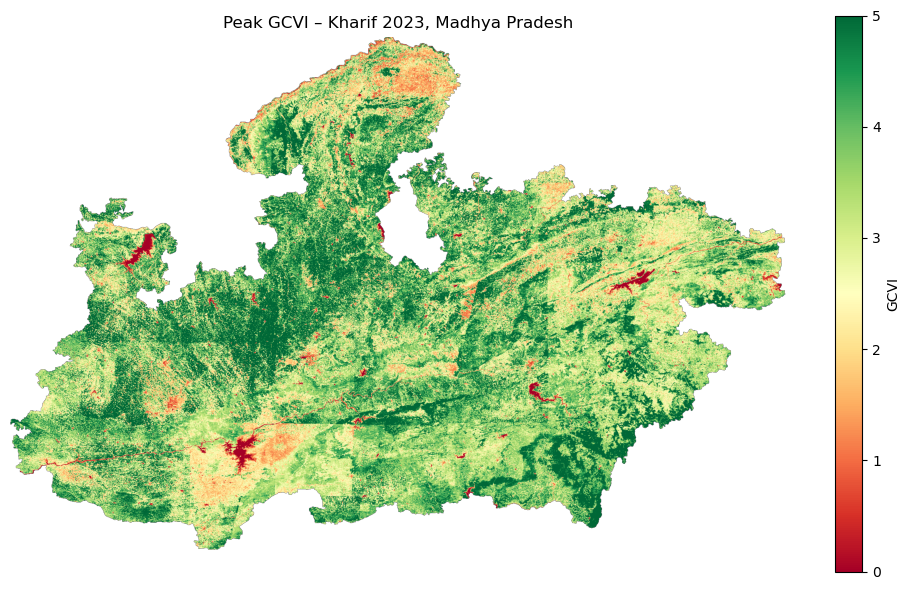

In [58]:
with rio.open('peak_gcvi_kharif_2023_mp_masked.tif') as src:
    peak_gcvi = src.read(1).astype('float32')
    # Handle no-data values
    peak_gcvi[peak_gcvi == src.nodata] = np.nan
    # Print basic statistics
    print(f"Min: {peak_gcvi[peak_gcvi>-2].min()}")
    print(f"Max: {peak_gcvi.max()}")
    print(f"Dimensions: {peak_gcvi.shape}")

plt.figure(figsize=(10, 6))
img = plt.imshow(peak_gcvi, cmap='RdYlGn', vmin=0, vmax=5)
plt.colorbar(img, label='GCVI')
plt.title('Peak GCVI – Kharif 2023, Madhya Pradesh')
plt.axis('off')
plt.tight_layout()
plt.show()

In [57]:
# How many pixels fall within different GCVI ranges?
unique, counts = np.unique(np.floor(peak_gcvi), return_counts=True)
for u, c in zip(unique, counts):
    print(f"GCVI {u}: {c} pixels")

GCVI -inf: 1172632 pixels
GCVI -1.0: 7753 pixels
GCVI 0.0: 14050 pixels
GCVI 1.0: 103187 pixels
GCVI 2.0: 300558 pixels
GCVI 3.0: 426291 pixels
GCVI 4.0: 280034 pixels
GCVI 5.0: 133904 pixels
GCVI 6.0: 56190 pixels
GCVI 7.0: 22385 pixels
GCVI 8.0: 8225 pixels
GCVI 9.0: 2978 pixels
GCVI 10.0: 1111 pixels
GCVI 11.0: 547 pixels
GCVI 12.0: 358 pixels
GCVI 13.0: 215 pixels
GCVI 14.0: 147 pixels
GCVI 15.0: 123 pixels
GCVI 16.0: 96 pixels
GCVI 17.0: 70 pixels
GCVI 18.0: 65 pixels
GCVI 19.0: 39 pixels
GCVI 20.0: 41 pixels
GCVI 21.0: 20 pixels
GCVI 22.0: 16 pixels
GCVI 23.0: 14 pixels
GCVI 24.0: 8 pixels
GCVI 25.0: 4 pixels
GCVI 26.0: 2 pixels
GCVI 30.0: 1 pixels


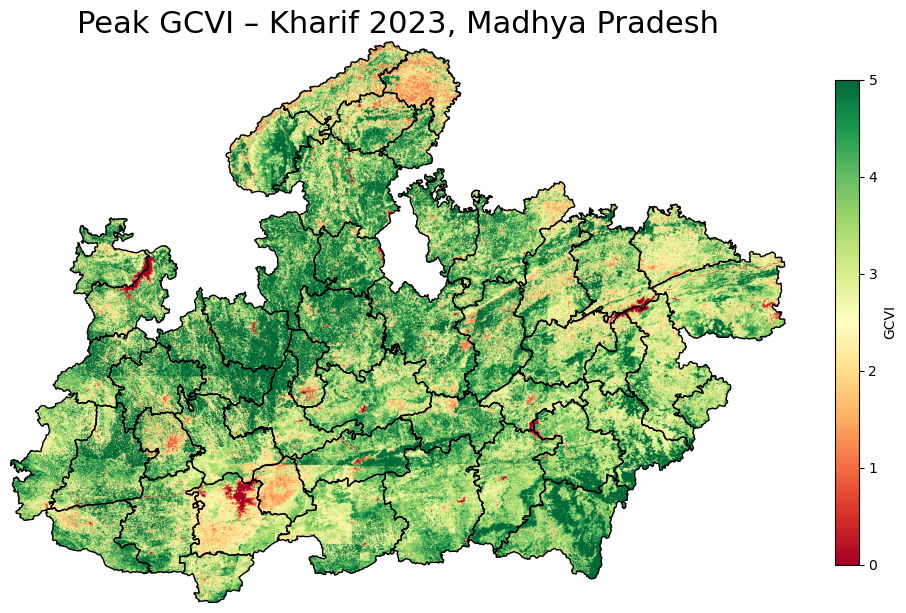

In [59]:
from rasterio.plot import show
import matplotlib.colors as mcolors

districts = gpd.read_file('data/MP_Districts_GAUL/MP_Districts_GAUL.shp')
districts = districts.to_crs('EPSG:4326')
fig, ax = plt.subplots(figsize=(10, 10))

with rio.open('peak_gcvi_kharif_2023_mp_masked.tif') as src:
    show(src, ax=ax, cmap='RdYlGn', vmin=0, vmax=5)
    districts = districts.to_crs(src.crs)

districts.plot(ax=ax, color='none', edgecolor='black', linewidth=1)
ax.set_title('Peak GCVI – Kharif 2023, Madhya Pradesh', fontsize=22)

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=mcolors.Normalize(vmin=0, vmax=5))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='GCVI', shrink=0.5)

plt.axis('off')
plt.tight_layout()
plt.show()

In [143]:
from rasterstats import zonal_stats
districts = gpd.read_file('data/MP_Districts_GAUL/MP_Districts_GAUL.shp')

stats = zonal_stats(
    districts,
    'peak_gcvi_kharif_2023_mp_masked.tif',
    stats=['mean', 'min', 'max', 'median'],
    nodata=-9999
)

# Attach results back to the geodataframe
districts['gcvi_mean']   = [s['mean']   for s in stats]
districts['gcvi_median'] = [s['median'] for s in stats]
districts['gcvi_min']    = [s['min']    for s in stats]
districts['gcvi_max']    = [s['max']    for s in stats]

print(districts[['ADM2_NAME', 'gcvi_mean', 'gcvi_median']].head(10))

     ADM2_NAME  gcvi_mean  gcvi_median
0  Hoshangabad   3.932917     3.875949
1     Jabalpur   3.412047     3.341144
2       Mandla   3.860015     3.698485
3     Mandsaur   3.415612     3.443796
4       Morena   2.820369     2.663133
5      Rajgarh   4.941135     4.936484
6   West Nimar   3.564601     3.466197
7      Barwani   3.625052     3.595900
8      Dindori   4.269522     3.641109
9        Harda   2.377869     2.175037


## District Yield Estimates

Source: https://upag.gov.in/dash-reports/desdistrictwisecompletedatasetreport

Units
- Area in Ha
- Production in Tonnes
- Yield kg/Ha

In [165]:
# Explore the district yield data in India for 2023

data = pd.read_csv('data/DES-District-Data-For-2023-24.csv')
data.head()

# Get relevant data: Madhya Pradesh, Kharif, Rice
filtered_data = data[(data['State'] == 'Madhya Pradesh') & (data['Season'] == 'Kharif') & (data['Crop'] == 'Rice')]
filtered_data.head()

,State,District,Crop,Season,Area-2023-24,Production-2023-24,Yield-2023-24
10998,Madhya Pradesh,Alirajpur,Rice,Kharif,4067.09,5861.23,1441.0
11037,Madhya Pradesh,Anuppur,Rice,Kharif,119003.58,176830.39,1486.0
11082,Madhya Pradesh,Ashoknagar,Rice,Kharif,24924.84,54008.33,2167.0
11119,Madhya Pradesh,Balaghat,Rice,Kharif,250344.86,459878.14,1837.0
11161,Madhya Pradesh,Barwani,Rice,Kharif,74.49,85.22,1144.0


In [168]:
# Generate summary stats for yield
filtered_data['Yield-2023-24'].describe()

count      49.000000
mean     1786.795918
std       504.306991
min       787.000000
25%      1292.000000
50%      1837.000000
75%      2197.000000
max      2578.000000
Name: Yield-2023-24, dtype: float64

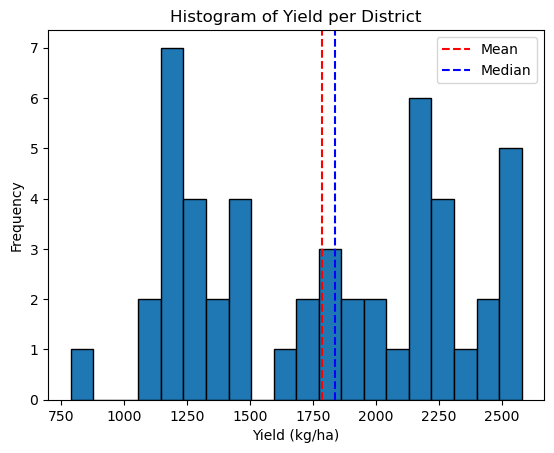

In [170]:
# Generate a histogrram of yield value per district from filtered_data with the mean and median visualized on the figures
plt.hist(filtered_data['Yield-2023-24'], bins=20, edgecolor='black')
plt.axvline(filtered_data['Yield-2023-24'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(filtered_data['Yield-2023-24'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.title('Histogram of Yield per District')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.show()

In [175]:
# Count the crop occurrences in Madhya Pradesh
filtered_data = data[(data['State'] == 'Madhya Pradesh') & (data['Season'] == 'Kharif') ]
filtered_data['Crop'].value_counts()

Crop
Maize                        52
Nutri/Coarse Cereals         52
Cereals                      52
Total Food Grains            52
Jowar                        51
Shree Anna /Nutri Cereals    51
Urad                         51
Moong                        49
Rice                         49
Tur                          48
Bajra                        33
Small Millets                30
Name: count, dtype: int64

Applied filters to get a subset of the district-level yield data:
    - state: Madhya Pradesh
    - season: kharif
    - exclude aggregate crop rows, e.g., cereal, total food grains, nutri/coarse cereals, pulses, oilseeds, and total oilseeds

Output: Weighted average yield (kg/ha)

In [125]:
df = pd.read_csv('data/DES-District-Data-For-2023-24.csv')

# Filter to Kharif only, exclude aggregate crop rows
kharif = df[
    (df['State'] == 'Madhya Pradesh') &
    (df['Season'] == 'Kharif') &
    (~df['Crop'].isin(['Cereals', 'Total Food Grains', 'Nutri/Coarse Cereals',
                       'Pulses', 'Oilseeds', 'Total Oilseeds']))
].copy()

kharif['Area-2023-24']       = pd.to_numeric(kharif['Area-2023-24'], errors='coerce')
kharif['Production-2023-24'] = pd.to_numeric(kharif['Production-2023-24'], errors='coerce')

# Weighted average yield = total production / total area per district
district_yield = kharif.groupby(['State', 'District']).apply(
    lambda x: pd.Series({
        'total_area':       x['Area-2023-24'].sum(),
        'total_production': x['Production-2023-24'].sum(),
        'weighted_yield':   x['Production-2023-24'].sum() / x['Area-2023-24'].sum()
    })
).reset_index()

district_yield['weighted_yield'] = district_yield['weighted_yield'] * 1000 # Convert yield to kg/ha
district_yield.head(10)

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_94952/4000921613.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  district_yield = kharif.groupby(['State', 'District']).apply(


,State,District,total_area,total_production,weighted_yield
0,Madhya Pradesh,Agar-Malwa,1497.97,2762.66,1844.269244
1,Madhya Pradesh,Alirajpur,77423.26,124599.37,1609.327352
2,Madhya Pradesh,Anuppur,158336.11,220469.26,1392.413013
3,Madhya Pradesh,Ashoknagar,59073.58,100018.41,1693.115772
4,Madhya Pradesh,Balaghat,262554.88,473520.64,1803.511098
5,Madhya Pradesh,Barwani,107003.31,273467.18,2555.688978
6,Madhya Pradesh,Betul,217890.28,586205.57,2690.370447
7,Madhya Pradesh,Bhind,183847.23,504033.38,2741.588111
8,Madhya Pradesh,Bhopal,27684.64,55751.34,2013.800432
9,Madhya Pradesh,Burhanpur,20876.39,51939.63,2487.960323


In [126]:
# Compare the district names in the yield data and the districts geodataframe
yield_districts    = set(district_yield['District'].str.strip().str.title())
gaul_districts     = set(districts['ADM2_NAME'].str.strip().str.title())

in_yield_not_gaul  = yield_districts - gaul_districts
in_gaul_not_yield  = gaul_districts - yield_districts
matched            = yield_districts & gaul_districts

print(f"Matched: {len(matched)}")
print(f"\nIn yield data but not in GAUL:\n", in_yield_not_gaul)
print(f"\nIn GAUL but not in yield data:\n", in_gaul_not_yield)

Matched: 44

In yield data but not in GAUL:
 {'Narsimhapur', 'Niwari', 'Agar-Malwa', 'Narmadapuram', 'Khargone (West Nimar)', 'Singrauli', 'Khandwa (East Nimar)', 'Alirajpur'}

In GAUL but not in yield data:
 {'West Nimar', 'Hoshangabad', 'East Nimar', 'Narsinghpur'}


In [127]:
# Change district names in yield data to match GAUL district names
name_mapping = {
    "Narsimhapur": "Narsinghpur",
    "Khargone (West Nimar)": "West Nimar",
    "Khandwa (East Nimar)": "East Nimar",
}
district_yield['District'] = district_yield['District'].replace(name_mapping)
print(district_yield['District'])


0       Agar-Malwa
1        Alirajpur
2          Anuppur
3       Ashoknagar
4         Balaghat
5          Barwani
6            Betul
7            Bhind
8           Bhopal
9        Burhanpur
10      Chhatarpur
11      Chhindwara
12           Damoh
13           Datia
14           Dewas
15            Dhar
16         Dindori
17            Guna
18         Gwalior
19           Harda
20          Indore
21        Jabalpur
22          Jhabua
23           Katni
24      East Nimar
25      West Nimar
26          Mandla
27        Mandsaur
28          Morena
29    Narmadapuram
30     Narsinghpur
31         Neemuch
32          Niwari
33           Panna
34          Raisen
35         Rajgarh
36          Ratlam
37            Rewa
38           Sagar
39           Satna
40          Sehore
41           Seoni
42         Shahdol
43        Shajapur
44         Sheopur
45        Shivpuri
46           Sidhi
47       Singrauli
48       Tikamgarh
49          Ujjain
50          Umaria
51         Vidisha
Name: Distri

**Merge data**

In [128]:
# Add yield data to the district geometries
districts['ADM2_NAME'] = districts['ADM2_NAME'].str.strip().str.title()
district_yield['District'] = district_yield['District'].str.strip().str.title()

districts = districts.merge(
    district_yield,
    left_on='ADM2_NAME',
    right_on='District',
    how='left'
)

print(f"Matched: {districts['District'].notna().sum()} / {len(districts)}")


Matched: 47 / 48


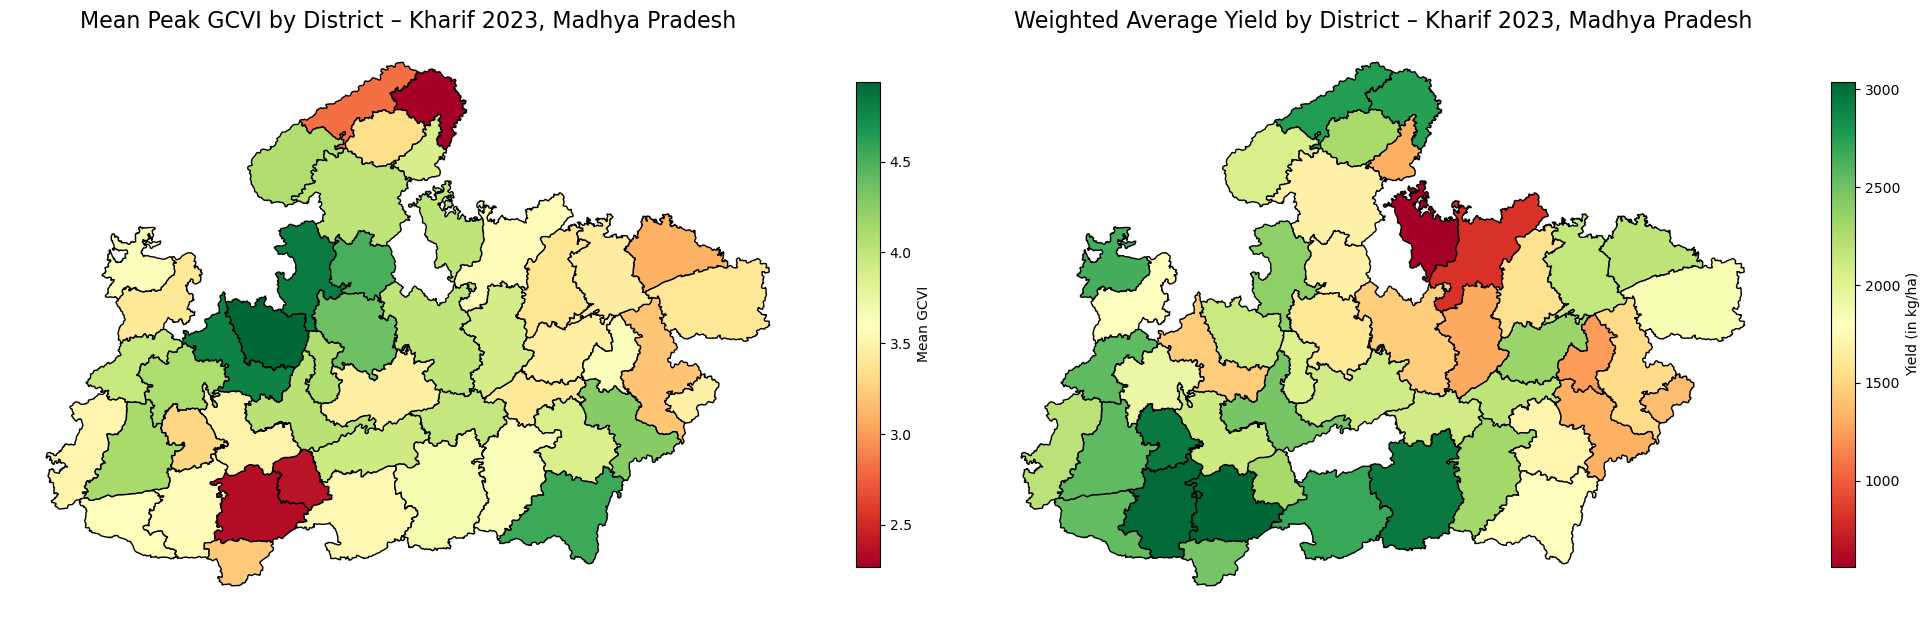

In [131]:
# Generate a map showing mean GCVI by district and a map of yield by district
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
districts.plot(column='gcvi_mean', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Mean GCVI'})
ax[0].set_title('Mean Peak GCVI by District – Kharif 2023, Madhya Pradesh', fontsize=16)
ax[0].axis('off')
districts.plot(column='weighted_yield', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Yield (in kg/ha)'})
ax[1].set_title('Weighted Average Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)
ax[1].axis('off')
plt.tight_layout()
plt.show()

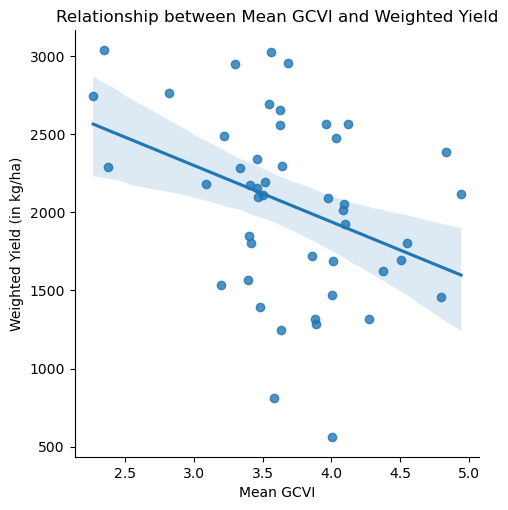

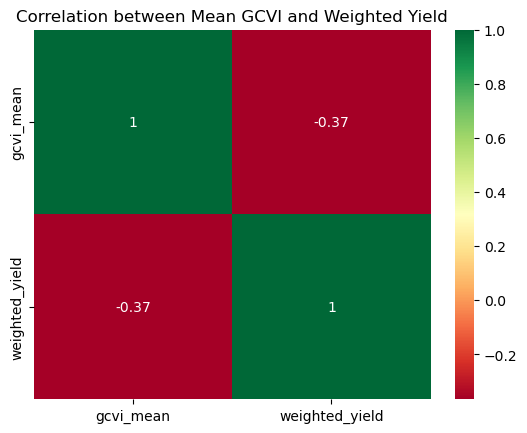

In [135]:
# Plot the relationship between Mean GCVI and Weighted Yield with the best fit line
sns.lmplot(x='gcvi_mean', y='weighted_yield', data=districts)
plt.title('Relationship between Mean GCVI and Weighted Yield')
plt.xlabel('Mean GCVI')
plt.ylabel('Weighted Yield (in kg/ha)')
plt.show()

# Compute the correlation between Mean GCVI and Weighted Yield
correlation = districts[['gcvi_mean', 'weighted_yield']].corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn')
plt.title('Correlation between Mean GCVI and Weighted Yield')
plt.show()

### Individual crop analysis
Filters
- State: Madhya Pradesh
- Season: Kharif
- Crops: Rice, Maize

In [138]:
kharif_mp_crops = df[
    (df['State'] == 'Madhya Pradesh') &
    (df['Season'] == 'Kharif') &
    (df['Crop'].isin(['Rice', 'Maize']))
].copy()

kharif_mp_crops['Yield-2023-24'] = pd.to_numeric(kharif_mp_crops['Yield-2023-24'], errors='coerce')

district_crop_yield = kharif_mp_crops.pivot(
    index='District',
    columns='Crop',
    values='Yield-2023-24'
).rename(columns={
    'Rice':  'rice_yield_kg_ha',
    'Maize': 'maize_yield_kg_ha'
}).reset_index()

district_crop_yield.head()

Crop,District,maize_yield_kg_ha,rice_yield_kg_ha
0,Agar-Malwa,2880.0,NaN
1,Alirajpur,2788.0,1441.0
2,Anuppur,2274.0,1486.0
3,Ashoknagar,2790.0,2167.0
4,Balaghat,3038.0,1837.0


In [144]:
# Add yield data to the district geometries
districts['ADM2_NAME'] = districts['ADM2_NAME'].str.strip().str.title()
district_crop_yield['District'] = district_crop_yield['District'].str.strip().str.title()

districts = districts.merge(
    district_crop_yield,
    left_on='ADM2_NAME',
    right_on='District',
    how='left'
)

print(f"Matched: {districts['District'].notna().sum()} / {len(districts)}")

Matched: 44 / 48


In [146]:
districts.head()

,Shape_Leng,STATUS,ADM1_CODE,ADM0_NAME,STR2_YEAR,ADM2_NAME,ADM0_CODE,EXP2_YEAR,Shape_Area,ADM2_CODE,DISP_AREA,ADM1_NAME,geometry,gcvi_mean,gcvi_median,gcvi_min,gcvi_max,District,maize_yield_kg_ha,rice_yield_kg_ha
0,5.068156,Member State,70079,India,1998,Hoshangabad,115,3000,0.589149,17728,NO,Madhya Pradesh,"POLYGON ((77.20344 22.56856, 77.20365 22.57193...",3.932917,3.875949,-0.447639,23.269230,NaN,NaN,NaN
1,4.610028,Member State,70079,India,1998,Jabalpur,115,3000,0.353783,17730,NO,Madhya Pradesh,"POLYGON ((79.34512 23.10806, 79.34545 23.11164...",3.412047,3.341144,-0.398414,12.744445,Jabalpur,2499.0,2227.0
2,5.267205,Member State,70079,India,1998,Mandla,115,3000,0.595051,17732,NO,Madhya Pradesh,"MULTIPOLYGON (((79.9459 22.9471, 79.94676 22.9...",3.860015,3.698485,-0.405827,11.478528,Mandla,2672.0,1882.0
3,5.188075,Member State,70079,India,1998,Mandsaur,115,3000,0.500490,17733,NO,Madhya Pradesh,"POLYGON ((74.88017 24.21648, 74.88671 24.22492...",3.415612,3.443796,-0.459885,20.168224,Mandsaur,2778.0,1198.0
4,5.576142,Member State,70079,India,1998,Morena,115,3000,0.451000,17734,NO,Madhya Pradesh,"POLYGON ((77.10938 26.22507, 77.11365 26.23136...",2.820369,2.663133,-0.217755,21.342592,Morena,2610.0,2433.0


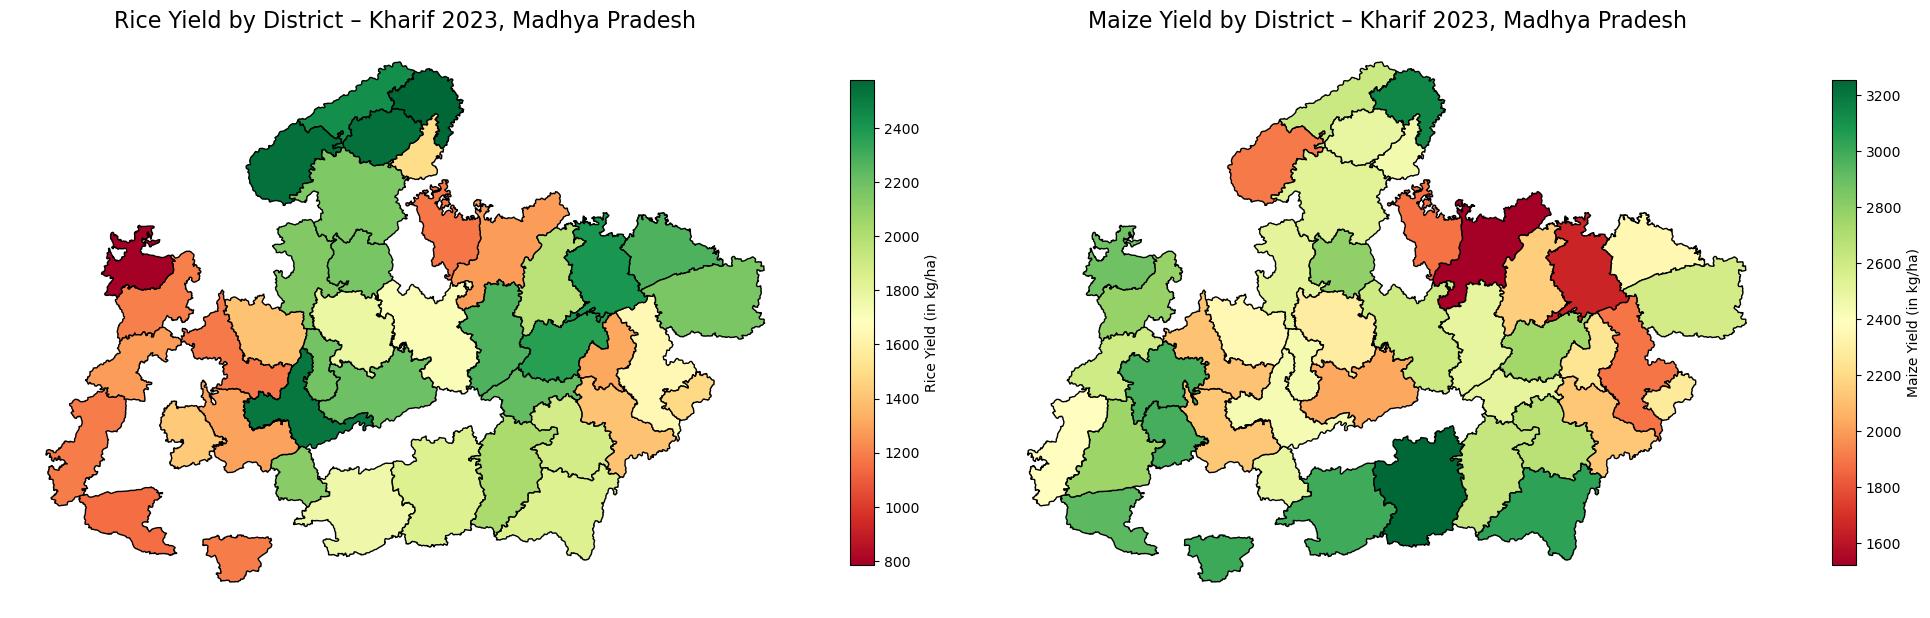

In [153]:
# Generate a map showing mean GCVI by district and a map of yield by district and the rice and maize yield by district
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

districts.plot(column='rice_yield_kg_ha', ax=ax[0], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Rice Yield (in kg/ha)'})
ax[0].set_title('Rice Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)

districts.plot(column='maize_yield_kg_ha', ax=ax[1], cmap='RdYlGn', edgecolor='black',
               legend=True,
               legend_kwds={'shrink': 0.5, 'label': 'Maize Yield (in kg/ha)'})
ax[1].set_title('Maize Yield by District – Kharif 2023, Madhya Pradesh', fontsize=16)

ax[0].axis('off')
ax[1].axis('off')
plt.tight_layout()
plt.show()

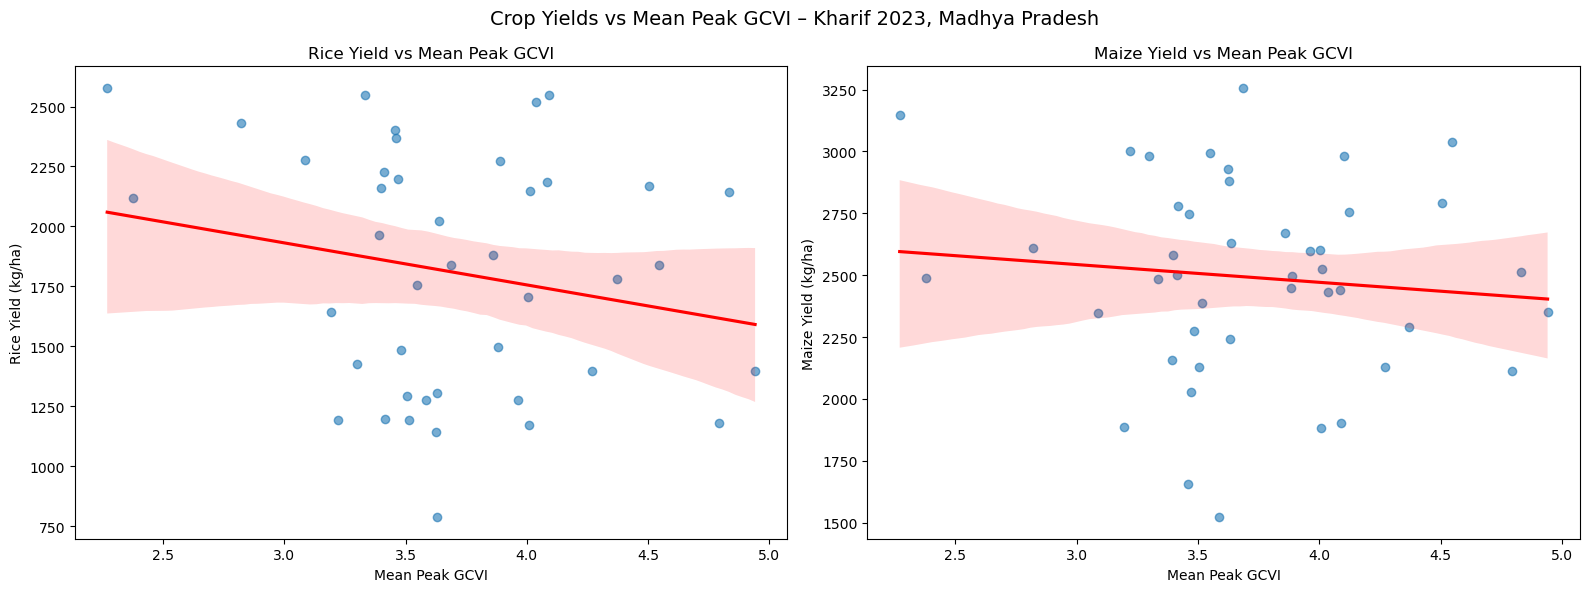

In [163]:
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=districts, x='gcvi_mean', y='rice_yield_kg_ha', ax=ax[0],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[0].set_title('Rice Yield vs Mean Peak GCVI')
ax[0].set_xlabel('Mean Peak GCVI')
ax[0].set_ylabel('Rice Yield (kg/ha)')

sns.regplot(data=districts, x='gcvi_mean', y='maize_yield_kg_ha', ax=ax[1],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
ax[1].set_title('Maize Yield vs Mean Peak GCVI')
ax[1].set_xlabel('Mean Peak GCVI')
ax[1].set_ylabel('Maize Yield (kg/ha)')

plt.suptitle('Crop Yields vs Mean Peak GCVI – Kharif 2023, Madhya Pradesh', fontsize=14)
plt.tight_layout()
plt.show()

Rice  — r: -0.203,  p: 0.197
Maize — r: -0.103, p: 0.507


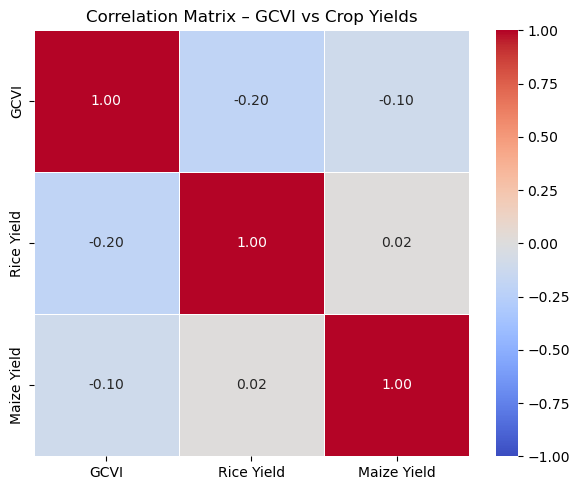

In [164]:
import scipy.stats as stats

# Compute correlations (drop NaN rows for each crop)
rice_data  = districts[['gcvi_mean', 'rice_yield_kg_ha']].dropna()
maize_data = districts[['gcvi_mean', 'maize_yield_kg_ha']].dropna()

rice_r,  rice_p  = stats.pearsonr(rice_data['gcvi_mean'],  rice_data['rice_yield_kg_ha'])
maize_r, maize_p = stats.pearsonr(maize_data['gcvi_mean'], maize_data['maize_yield_kg_ha'])

print(f"Rice  — r: {rice_r:.3f},  p: {rice_p:.3f}")
print(f"Maize — r: {maize_r:.3f}, p: {maize_p:.3f}")

# Visualize correlation matrix
corr_df = districts[['gcvi_mean', 'rice_yield_kg_ha', 'maize_yield_kg_ha']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            ax=ax, linewidths=0.5,
            xticklabels=['GCVI', 'Rice Yield', 'Maize Yield'],
            yticklabels=['GCVI', 'Rice Yield', 'Maize Yield'])
ax.set_title('Correlation Matrix – GCVI vs Crop Yields')
plt.tight_layout()
plt.show()